# 05 — ARIMA Stationarity Analysis & Parameter Tuning

**Mục tiêu của Notebook này:**
Mô hình ARIMA(p, d, q) cần 3 tham số cốt lõi. Chúng ta sẽ đi tìm chúng qua các bước:
1. **Tham số d (Differencing):** Kiểm tra tính dừng (Stationarity) của chuỗi thời gian bằng kiểm định Augmented Dickey-Fuller (ADF Test). Nếu chuỗi không dừng, ta sẽ lấy sai phân bậc 1, bậc 2... cho đến khi dừng để chốt giá trị $d$.
2. **Tham số p (AR) và q (MA):**  Vẽ biểu đồ ACF (Autocorrelation) và PACF (Partial Autocorrelation) trên chuỗi đã dừng để xác định bậc Tự hồi quy ($p$) và bậc Trung bình trượt ($q$).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Tùy chỉnh hiển thị
plt.rcParams.update({'figure.dpi': 120})

# Đọc file CSV chứa chuỗi thời gian RMS mà ta đã tạo ở Notebook 04
input_file = "ds003029_arima_input_timeseries.csv"
df = pd.read_csv(input_file)

print(f"Dữ liệu có {len(df)} dòng.")
df.head()

Dữ liệu có 152 dòng.


,t_mid_s,rms
0,0.9995,0.001476
1,1.9995,0.001270
2,2.9995,0.000856
3,3.9995,0.000830
4,4.9995,0.000959


## Bước 1: Kiểm định tính dừng (Augmented Dickey-Fuller Test)
Mô hình ARIMA yêu cầu dữ liệu phải có tính "dừng" (trung bình và phương sai không đổi theo thời gian). 
* **H0 (Giả thuyết không):** Chuỗi thời gian KHÔNG dừng (có trend hoặc tính mùa vụ).
* **H1 (Giả thuyết thay thế):** Chuỗi thời gian ĐÃ dừng.
* **Quy tắc:** Nếu P-value < 0.05, ta bác bỏ H0 $\rightarrow$ Chuỗi đã dừng $\rightarrow$ $d = 0$. Ngược lại, ta phải lấy sai phân (differencing).

--- Kết quả ADF Test cho Chuỗi RMS Gốc ---
ADF Statistic: -2.5665
p-value: 0.1001
=> Dữ liệu CHƯA DỪNG (Non-Stationary). Cần lấy sai phân (Differencing)!

--- Kết quả ADF Test cho Chuỗi RMS sau Sai phân bậc 1 (d=1) ---
ADF Statistic: -4.8599
p-value: 0.0000
=> Dữ liệu ĐÃ DỪNG (Stationary). Có thể chuyển sang vẽ ACF/PACF.



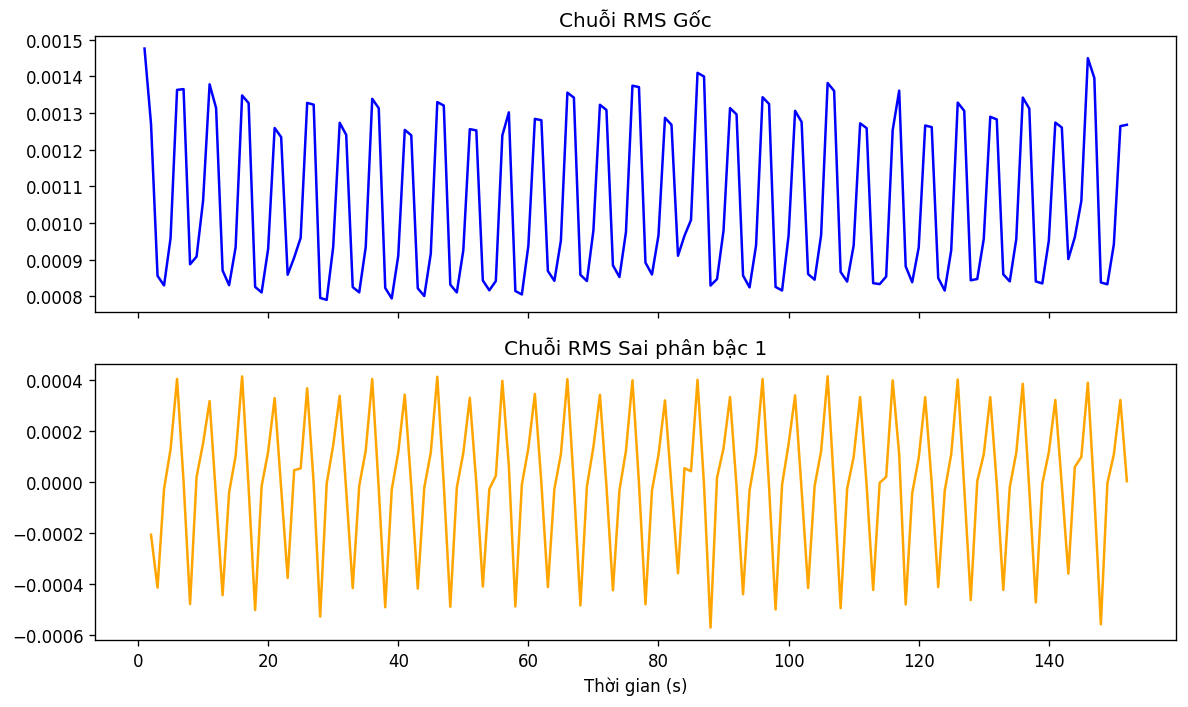

In [3]:
# Định nghĩa hàm in kết quả ADF Test
def adf_test(timeseries, title=""):
    print(f'--- Kết quả ADF Test cho {title} ---')
    result = adfuller(timeseries, autolag='AIC')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("=> Dữ liệu ĐÃ DỪNG (Stationary). Có thể chuyển sang vẽ ACF/PACF.\n")
    else:
        print("=> Dữ liệu CHƯA DỪNG (Non-Stationary). Cần lấy sai phân (Differencing)!\n")

# Kiểm tra chuỗi RMS gốc
rms_series = df['rms'].dropna()
adf_test(rms_series, "Chuỗi RMS Gốc")

# Lấy sai phân bậc 1 (Differencing d=1) và kiểm tra lại
df['rms_diff_1'] = df['rms'].diff().dropna()
rms_diff_1 = df['rms_diff_1'].dropna()
adf_test(rms_diff_1, "Chuỗi RMS sau Sai phân bậc 1 (d=1)")

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(df['t_mid_s'], df['rms'], color='blue')
axes[0].set_title('Chuỗi RMS Gốc')
axes[1].plot(df['t_mid_s'], df['rms_diff_1'], color='orange')
axes[1].set_title('Chuỗi RMS Sai phân bậc 1')
plt.xlabel('Thời gian (s)')
plt.tight_layout()
plt.show()

## Bước 2: Tìm tham số p và q qua ACF/PACF
Lưu ý: Chúng ta vẽ ACF và PACF trên **chuỗi đã dừng** (chuỗi sai phân bậc 1: `rms_diff_1`).
* **PACF (Partial Autocorrelation):** Xác định bậc $p$ (AutoRegressive - AR). Nhìn xem biểu đồ cắt ngưỡng ý nghĩa (vùng xám) ở độ trễ (lag) thứ mấy.
* **ACF (Autocorrelation):** Xác định bậc $q$ (Moving Average - MA). Tương tự, nhìn xem biểu đồ cắt ngưỡng ý nghĩa ở độ trễ thứ mấy.

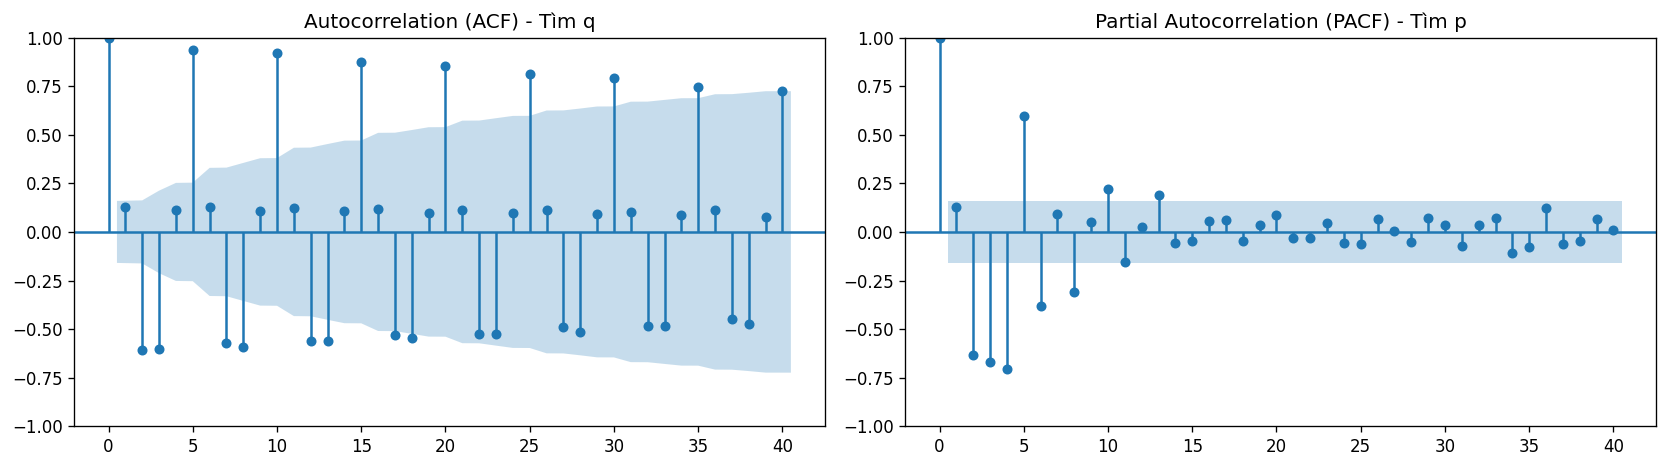

In [4]:
# Vẽ ACF và PACF trên chuỗi đã lấy sai phân bậc 1
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Vẽ ACF để tìm q
plot_acf(rms_diff_1, ax=axes[0], lags=40, title="Autocorrelation (ACF) - Tìm q")

# Vẽ PACF để tìm p
plot_pacf(rms_diff_1, ax=axes[1], lags=40, title="Partial Autocorrelation (PACF) - Tìm p", method='ywm')

plt.tight_layout()
plt.show()